In [213]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt

In [214]:
# 1. Data setup
X = np.array([[1.0, 3.0], [4.0, 10.0]])

y = np.array([5.0, 6.0])

m = np.array([-1.0, 2.0])
b = np.array([1.0])


In [215]:
def predict(X, m, b):
    return X @ m + b


def cost(params, X, y):
    m_ = params[:2]
    b_ = params[2:]
    y_hat = predict(X, m_, b_)
    e = y_hat - y
    return np.mean(e ** 2)


In [216]:
# 3. Analytical gradient, the method we used in the part3
#    dJ/dm = (2/n) * X^T @ (y_hat - y)
#    dJ/db = (2/n) * (y_hat - y)
def analytical_gradient(X, y, m, b):
    y_hat = predict(X, m, b)
    e = y_hat - y
    dJ_dm = (2 / n) * (X.T @ e)
    dJ_db = (2 / n) * e
    return dJ_dm, dJ_db


In [217]:
# 4. numerical gradient, the assignment required using SciPy
# otherwise we could have gone for analytical gradient instead

def numerical_gradient(m, b, X, y):
    params = np.concatenate([m, b])
    epsi = 1e-6
    grad = approx_fprime(params, cost, epsi, X, y)
    return grad[:2], grad[2:]



In [218]:
# 5. Gradient Descent loop
learning_rate = 0.01
n_iterations = 3

m_history = [m.copy()]
b_history = [b.copy()]
cost_history = [cost(np.concatenate([m, b]), X, y)]

for it in range(1, n_iterations + 1):
    # predict
    y_hat = predict(X, m, b)

    # error
    error = y_hat - y

    # numerical gradients
    # Noticed that numerical is less precise than the analytical
    # Maybe because of floating-point arithmetic (0.1 + 0.2 = 0.30000000000000004)
    dJ_dm, dJ_db = numerical_gradient(m, b, X, y)
    print(f"numerical gradient: m= {dJ_dm}, b= {dJ_db}")

    # analytical gradients
    dJ_dm = (2 / n) * (X.T @ error)
    dJ_db = (2 / n) * np.sum(error, keepdims=True)
    print(f"analytical gradient: m= {dJ_dm}, b= {dJ_db}")


    # parameter update
    m = m - learning_rate * dJ_dm
    b = b - learning_rate * dJ_db

    # record history
    m_history.append(m.copy())
    b_history.append(b.copy())
    current_cost = cost(np.concatenate([m, b]), X, y)
    cost_history.append(current_cost)

m_history = np.array(m_history)
b_history = np.array(b_history)
cost_history = np.array(cost_history)


numerical gradient: m= [ 45.0000085  113.00005452], b= [12.00000102]
analytical gradient: m= [ 45. 113.], b= [12.]
numerical gradient: m= [-11.8399915 -31.0799455], b= [-5.179999]
analytical gradient: m= [-11.84 -31.08], b= [-5.18]
numerical gradient: m= [3.7962085 8.5618545], b= [-0.443999]
analytical gradient: m= [3.7962 8.5618], b= [-0.444]


In [219]:
# 6. output the results
y_hat_final = predict(X, m, b)
print("\nFinal m:", np.round(m, 6))
print("Final b:", np.round(b, 6))
print("Final predictions y_hat:", np.round(y_hat_final, 6))
print("Actual y:", y)



Final m: [-1.369562  1.095182]
Final b: [0.93624]
Final predictions y_hat: [2.852224 6.409812]
Actual y: [5. 6.]


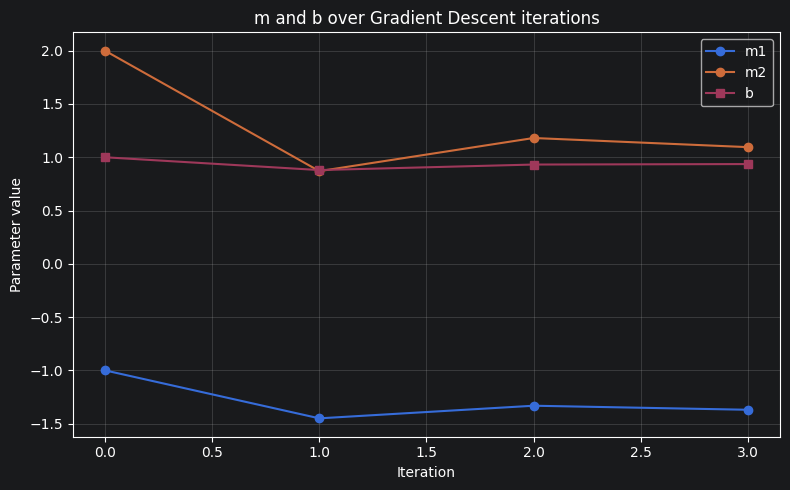

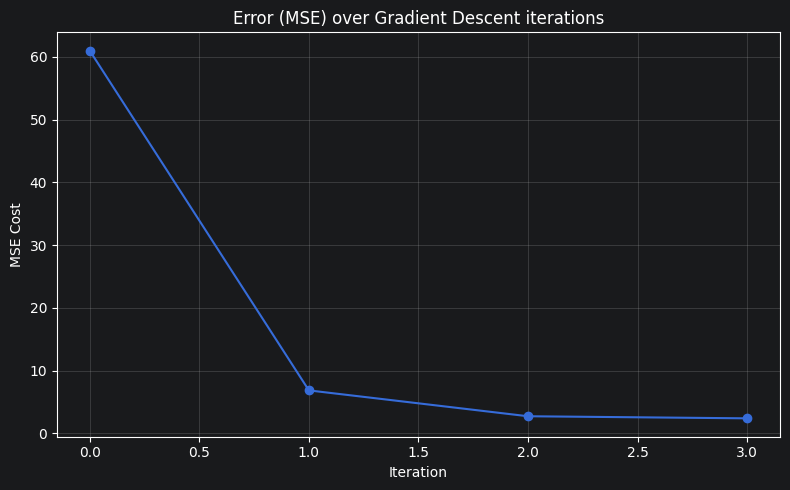

In [220]:
# Plot 1: m and b values over iterations
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(m_history[:, 0], label="m1", marker="o")
ax1.plot(m_history[:, 1], label="m2", marker="o")
ax1.plot(b_history[:, 0], label="b", marker="s")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Parameter value")
ax1.set_title("m and b over Gradient Descent iterations")
ax1.legend()
ax1.grid(True, alpha=0.3)
fig1.tight_layout()

# Plot 2: cost (error) over iterations
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(cost_history, marker="o")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("MSE Cost")
ax2.set_title("Error (MSE) over Gradient Descent iterations")
ax2.grid(True, alpha=0.3)
fig2.tight_layout()